# Домашнее задание 6. Графовые нейронные сети: проектирование и обучение простой GNN под прикладную задачу

В этом домашнем задании вы шаг за шагом:

- сформулируете прикладную задачу в графовой постановке;
- реализуете и обучите простую GCN-модель для классификации узлов;
- реализуете и обучите упрощенный вариант GraphSAGE и сравните его с GCN;
- добавите graph pooling и решите простую graph-level задачу на синтетических графах.

Все задачи — кодовые, с акцентом на понимание механики message passing, форм тензоров
и влияния архитектурных решений на качество моделей.


## Структура домашней работы

Домашнее задание состоит из 9 задач, разделенных на три уровня сложности:

- Простые задачи: 1–4.
- Средние задачи: 5–7.
- Сложные задачи: 8–9.

Задачи идут от базового представления графов к полноценным графовым нейронным сетям
для классификации узлов и графов.


## Цели занятия

После выполнения этого домашнего задания вы сможете:

1. Понять, как формулировать прикладную задачу в виде графовой модели с узлами, ребрами и признаками.
2. Освоить базовую реализацию GCN-слоя и message passing в матричной форме.
3. Научиться обучать и отлаживать простую GCN для классификации узлов на синтетических данных.
4. Проанализировать отличия GraphSAGE от GCN и влияние разных типов агрегации соседей.
5. Сравнить узловые и графовые постановки через добавление pooling-уровня и graph-level классификатора.
6. Интерпретировать полученные эмбеддинги узлов и графов и сделать практические выводы по выбору архитектуры.


## Теоретическая часть

### Граф как структура данных

Граф $G = (V, E)$ задается множеством узлов $V$ и ребер $E$. Узлам и ребрам часто сопоставляют
признаки: матрица признаков узлов $X \in \mathbb{R}^{N \times D}$, где $N$ — число узлов, $D$ — размерность признаков.
Структура графа кодируется матрицей смежности $A \in \mathbb{R}^{N \times N}$, где $A_{ij} = 1$, если есть ребро между
узлами $i$ и $j$, и $0$ иначе.

### Message passing и GNN

Идея графовых нейронных сетей: узлы итеративно обмениваются информацией с соседями. На каждом слое
обновление признаков узла можно записать в общем виде как
$$h_i^{(k+1)} = \mathrm{UPDATE}\Bigl(h_i^{(k)}, \mathrm{AGGREGATE}(\{h_j^{(k)} : j \in \mathit{N}(i)\})\Bigr),$$
где $\mathit{N}(i)$ — множество соседей узла $i$. В матричной форме это приводит к операциям вида
$H^{(k+1)} = \sigma(\tilde{A} H^{(k)} W^{(k)})$, где $\tilde{A}$ — нормализованная матрица смежности.

### GCN и GraphSAGE

- **GCN** использует фиксированную нормализующую матрицу $\tilde{A}$ и агрегирует соседей через
  умножение $\tilde{A} H$.
- **GraphSAGE** явно задает функцию агрегации (mean / sum / max) и обновляет признак узла как функцию
  от его собственного признака и агрегированных признаков соседей, что делает модель более гибкой
  и удобной для индуктивных сценариев.

В этом задании мы будем реализовывать простые варианты этих идей, не зависящие от конкретных фреймворков
для графов, используя только NumPy / PyTorch и NetworkX.

## Настройка окружения

In [1]:
# Импорт
import random

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Используемое устройство:", DEVICE)


Используемое устройство: cpu


---

# ПРОСТЫЕ ЗАДАЧИ (1–4)

В этих задачах мы научимся представлять графы в виде матриц, задавать признаки узлов
и реализовывать один шаг агрегирования признаков соседей.


## Задача 1. Построение графа и матрицы смежности

### Постановка задачи

1. Сконструировать небольшой неориентированный граф с помощью NetworkX.
2. Получить его матрицу смежности в виде NumPy-массива.
3. Визуализировать граф и проверить согласованность между матрицей и рисунком.

### Теоретический минимум

- Матрица смежности полностью задает структуру графа.
- Степень узла равна сумме элементов соответствующей строки или столбца матрицы \(A\).


Форма матрицы смежности A: (8, 8)
[[0. 1. 1. 1. 0. 0. 0. 0.]
 [1. 0. 1. 0. 1. 0. 0. 0.]
 [1. 1. 0. 0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 1. 1. 1. 0.]
 [0. 1. 1. 1. 0. 1. 0. 0.]
 [0. 0. 0. 1. 1. 0. 1. 1.]
 [0. 0. 0. 1. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0.]]


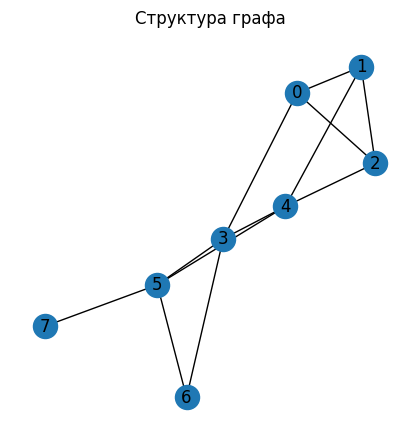

Степени узлов: [3 3 3 4 4 4 2 1]


In [2]:
# Задача 1. Построение графа и матрицы смежности

# TODO: Создайте граф G с помощью nx.Graph()
G = nx.Graph()

# TODO: Добавьте ребра. Используйте набор из 10–12 ребер на 6–8 узлов.
edges_lst = [
    (0, 1), (0, 2), (0, 3), (1, 2),
    (1, 4), (2, 4), (3, 4), (3, 5),
    (3, 6), (4, 5), (5, 6), (5, 7)
]

G.add_edges_from(edges_lst)

# TODO: Получите матрицу смежности A в виде NumPy-массива (dtype=np.float32)
A = nx.to_numpy_array(G, dtype=np.float32)
print("Форма матрицы смежности A:", A.shape)
print(A)

# TODO: Визуализируйте граф (с метками узлов)
plt.figure(figsize=(4, 4))
pos = nx.spring_layout(G, seed=SEED)
# ваш код здесь
nx.draw(G, pos, with_labels=True)
plt.title("Структура графа")
plt.show()

# TODO: Вычислите степени всех узлов через матрицу смежности
degrees = A.sum(axis=1).astype(int)
print("Степени узлов:", degrees)


**Интерпретация:**  
Матрица смежности, граф и степени узлов отражают одну и ту же структуру. Например, узел 0 связан с тремя узлами 1, 2, 3 - это видно на графе, по матрице смежности и степень узла также равна трём; с другой стороны, узел 7 связан только с узлом 5 и поэтому его степень равна единице и т.д.

## Задача 2. Признаки узлов и агрегирование соседей

### Постановка задачи

1. Задать простые числовые признаки для каждого узла (например, константа и степень).
2. Реализовать агрегирование признаков соседей через умножение \(A X\).
3. Проинтерпретировать полученные агрегированные признаки.

### Теоретический минимум

- Матрица признаков $(X \in \mathbb{R}^{N×D})$ хранит по строкам признаки узлов.
- Умножение \(A X\) дает для каждого узла сумму признаков его соседей.


In [3]:
# Задача 2. Признаки узлов и агрегирование соседей

num_nodes = A.shape[0]

# TODO: Создайте матрицу признаков X формы (N, 2).
# Признак 1: константа (единица для каждого узла)
# Признак 2: нормированная степень узла (от 0 до 1)
degrees =  A.sum(axis=1).astype(np.float32)
deg_norm = (degrees - degrees.min()) / (degrees.max() - degrees.min())

X = np.ones((num_nodes, 2), dtype=np.float32)  # форма: (N, 2), dtype=np.float32
X[:, 1] = deg_norm
print("Форма X:", X.shape)
print("Первые строки X:", X[:5])

# TODO: Выполните шаг агрегирования: AX = A @ X
AX = A @ X
print("Форма AX:", AX.shape)
print("Первые строки AX (агрегированные признаки соседей):", AX[:5])

# TODO: Проверьте вручную для нескольких узлов:
# выведите список соседей и соответствующий агрегированный признак
for i in range(num_nodes):
    neighbors = list(G.neighbors(i))
    # ваш код здесь
    print(f'Узел {i}: соседи {neighbors}, агрегированный признак = {AX[i]}')

Форма X: (8, 2)
Первые строки X: [[1.        0.6666667]
 [1.        0.6666667]
 [1.        0.6666667]
 [1.        1.       ]
 [1.        1.       ]]
Форма AX: (8, 2)
Первые строки AX (агрегированные признаки соседей): [[3.        2.3333335]
 [3.        2.3333335]
 [3.        2.3333335]
 [4.        3.       ]
 [4.        3.3333335]]
Узел 0: соседи [1, 2, 3], агрегированный признак = [3.        2.3333335]
Узел 1: соседи [0, 2, 4], агрегированный признак = [3.        2.3333335]
Узел 2: соседи [0, 1, 4], агрегированный признак = [3.        2.3333335]
Узел 3: соседи [0, 4, 5, 6], агрегированный признак = [4. 3.]
Узел 4: соседи [1, 2, 3, 5], агрегированный признак = [4.        3.3333335]
Узел 5: соседи [3, 4, 6, 7], агрегированный признак = [4.        2.3333333]
Узел 6: соседи [3, 5], агрегированный признак = [2. 2.]
Узел 7: соседи [5], агрегированный признак = [1. 1.]


**Интерпретация:**  
Из сопоставления номера узла, его соседей и его агрегированных признаков видно, что каждый из двух агрегированных признаков узла - это сумма соответтсвующих признаков соседних узлов.

## Задача 3. Нормализованный шаг GCN

### Постановка задачи

1. Добавить к графу петли (self-loops).
2. Построить нормализованную матрицу смежности $\tilde{A} = D^{-1/2}(A + I)D^{-1/2}$.
3. Выполнить шаг $H = \tilde{A} X W$ и проверить формы тензоров.

### Теоретический минимум

- Добавление петель позволяет узлу сохранить собственные признаки при обновлении.
- Нормализация по степеням стабилизирует масштаб активаций.


In [4]:
# Задача 3. Нормализованный шаг GCN

# TODO: Добавьте петли: A_hat = A + I
I = np.eye(num_nodes, dtype=np.float32)
A_hat = A + I

# TODO: Вычислите диагональную матрицу степеней D_hat для A_hat
D_hat = np.diag((A_hat.sum(axis=1)).astype(np.float32))

# TODO: Постройте D^{-1/2} как диагональную матрицу
# Подсказка: добавьте 1e-8, чтобы избежать деления на ноль
D_inv_sqrt = np.diag(1.0 / np.sqrt(D_hat.diagonal() + 1e-8))

# TODO: Нормализуйте: A_norm = D_inv_sqrt @ A_hat @ D_inv_sqrt
A_norm = D_inv_sqrt @ A_hat @ D_inv_sqrt
print("Форма A_norm:", A_norm.shape)

# TODO: Задайте случайную матрицу весов W формы (in_dim, out_dim)
in_dim = X.shape[1]
out_dim = 4
W = (np.random.randn(in_dim, out_dim).astype(np.float32)) * 0.1  # np.random.randn, масштаб ~0.1
print("Форма W:", W.shape)

# TODO: Выполните один шаг GCN: H = A_norm @ X @ W
H = A_norm @ X @ W
print("Форма H:", H.shape)
print("Первые строки H:", H[:5])

Форма A_norm: (8, 8)
Форма W: (2, 4)
Форма H: (8, 4)
Первые строки H: [[ 0.03141693 -0.03040382  0.17733233  0.20381533]
 [ 0.03141693 -0.03040382  0.17733233  0.20381533]
 [ 0.03141693 -0.03040382  0.17733233  0.20381533]
 [ 0.03417979 -0.03451116  0.2019533   0.22885358]
 [ 0.03098627 -0.03550806  0.20966263  0.22842032]]


**Интерпретация:**  
Полученная форма матрицы H указывает на то, что количество элементов сохранилось прежним (8), а размерность признакового пространства увеличилась до четырёх (out_dim)  
Из значений в строках матрицы H видно, что даже после одного шага GCN узлы с одинаковыми связями (например, 0, 1 и 2) получают одинаковые признаки, а узлы 3 и 4, сильно отличающиеся по своим связям от первых трёх узлов, в новом пространстве также отличаются своими признаками.


## Задача 4. Простая узловая задача на синтетическом графе

### Постановка задачи

1. Сгенерировать синтетический граф с двумя группами узлов (два класса).
2. Задать базовые признаки узлов.
3. Реализовать один шаг GCN (без обучения) и визуализировать узлы в 2D-пространстве признаков.

### Теоретический минимум

- Даже один шаг message passing может сделать узлы одного класса более похожими друг на друга
  в скрытом пространстве.


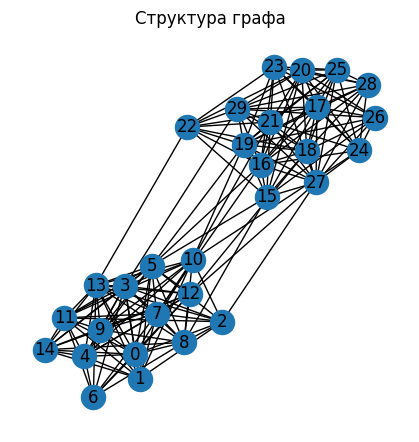

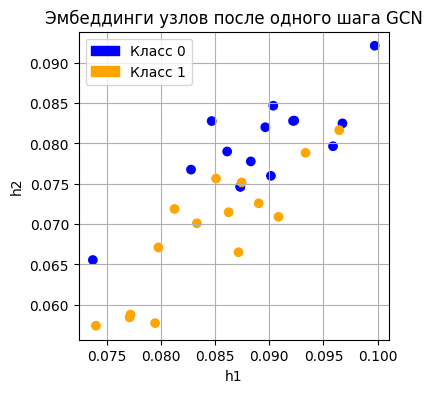

In [5]:
# Задача 4. Узловая задача и визуализация эмбеддингов

# TODO: Сгенерируйте граф с двумя кластерами по 15 узлов
# nx.planted_partition_graph(l=..., k=..., p_in=..., p_out=..., seed=SEED)
G2 = nx.planted_partition_graph(l=2, k=15, p_in=0.8, p_out=0.05, seed=SEED)
A2 = nx.to_numpy_array(G2, dtype=np.float32)
num_nodes2 = A2.shape[0]

# TODO: Задайте метки узлов: первые 15 — класс 0, вторые 15 — класс 1
labels2 = np.array([0] * 15 + [1] * 15, dtype=np.int32)

# TODO: Постройте матрицу признаков X2 аналогично Задаче 2
deg2 = A2.sum(axis=1).astype(np.float32)
deg2_norm = (deg2 - deg2.min()) / (deg2.max() - deg2.min())
X2 = np.ones((num_nodes2, 2), dtype=np.float32)  # форма (N, 2)
X2[:, 1] = deg2_norm

# TODO: Выполните нормализованный шаг GCN (аналогично Задаче 3)
A2_hat = A2 + np.eye(num_nodes2, dtype=np.float32)
row_sums = A2_hat.sum(axis=1)
D_inv_sqrt = np.diag(1.0 / np.sqrt(row_sums + 1e-8).astype(np.float32))
A2_norm = D_inv_sqrt @ A2_hat @ D_inv_sqrt

# TODO: Задайте случайную матрицу весов W2 формы (2, 2)
np.random.seed(SEED)
W2 = np.random.randn(2, 2).astype(np.float32) * 0.1

# TODO: Вычислите H2 = A2_norm @ X2 @ W2
H2 = A2_norm @ X2 @ W2

plt.figure(figsize=(4, 4))
pos2 = nx.spring_layout(G2, seed=SEED)
nx.draw(G2, pos2, with_labels=True)
plt.title("Структура графа")
plt.show()

# TODO: Визуализируйте H2 как scatter plot:
# ось X — H2[:, 0], ось Y — H2[:, 1], цвет — метка класса
plt.figure(figsize=(4, 4))
# ваш код здесь
colors = ['blue' if lbl == 0 else 'orange' for lbl in labels2]
scatter = plt.scatter(H2[:, 0], H2[:, 1], c=colors)
class_0 = mpatches.Patch(color='blue', label='Класс 0')
class_1 = mpatches.Patch(color='orange', label='Класс 1')
plt.legend(handles=[class_0, class_1], loc='best')
plt.xlabel("h1")
plt.ylabel("h2")
plt.title("Эмбеддинги узлов после одного шага GCN")
plt.grid(True)
plt.show()

**Интерпретация:**  
В данном случае сама структура графа несёт информацию о каждом из классов. Признаки, полученные после одного шага GCN, обеспечивают корректную кластеризацию для большей части узлов.

---

# СРЕДНИЕ ЗАДАЧИ (5–7)

Теперь будем обучать GCN и GraphSAGE на узловой задаче и сравнивать их результаты.


## Задача 5. Обучение простого GCN для классификации узлов

### Постановка задачи

1. Реализовать один GCN-слой в PyTorch с использованием нормализованной матрицы смежности.
2. Собрать из него простую модель с двумя слоями для классификации узлов на синтетическом графе.
3. Обучить модель и оценить качество на обучающем и тестовом подмножествах узлов.

### Теоретический минимум

- GCN-слой: $H^{(l+1)} = \sigma(\tilde{A} H^{(l)} W^{(l)})$.
- В узловой задаче разделение на train / test обычно делается по узлам, а не по графам.


In [6]:
# Задача 5. Реализация и обучение GCN

torch.manual_seed(SEED)

# --- Шаг 1. Подготовка данных ---
def numpy_to_torch(x):
    return torch.from_numpy(x).float()

# TODO: Конвертируйте A2_norm, X2, labels2 в тензоры и перенесите на DEVICE
A2_norm_t = numpy_to_torch(A2_norm).to(DEVICE)
X2_t = numpy_to_torch(X2).to(DEVICE)
labels2_t = torch.from_numpy(labels2).long().to(DEVICE)

# --- Шаг 2. Разбиение узлов ---
# TODO: Перемешайте индексы и разделите на train (70%) и test (30%)
idx = np.arange(num_nodes2)
# ваш код здесь
np.random.seed(SEED)
idx_perm = np.random.permutation(idx)
train_size = int(0.7 * num_nodes2)
idx_train = idx_perm[:train_size]
idx_test = idx_perm[train_size:]

# --- Шаг 3 & 4. Архитектура модели ---
class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        # TODO: инициализируйте линейный слой
        self.linear = nn.Linear(in_dim, out_dim)

    def forward(self, x, A_norm):
        # TODO: умножьте A_norm @ x, затем примените линейный слой
        A_norm_x = A_norm @ x
        return self.linear(A_norm_x)

class GCN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        # TODO: два слоя GCNLayer
        self.lay_1 = GCNLayer(in_dim, hidden_dim)
        self.lay_2 = GCNLayer(hidden_dim, out_dim)

    def forward(self, x, A_norm):
        # TODO: первый слой → ReLU → второй слой
        temp = F.relu(self.lay_1(x, A_norm))
        res = self.lay_2(temp, A_norm)
        return res

# --- Шаг 5. Оптимизатор и функция потерь ---
model_gcn = GCN(in_dim=2, hidden_dim=16, out_dim=2).to(DEVICE)
# TODO: настройте Adam (lr=0.01, weight_decay=5e-4) и CrossEntropyLoss
optimizer = torch.optim.Adam(model_gcn.parameters(), lr=0.01, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

# --- Шаг 6. Цикл обучения ---
EPOCHS = 200

for epoch in range(EPOCHS):
    model_gcn.train()
    optimizer.zero_grad()
    # TODO: forward pass
    logits = model_gcn(X2_t, A2_norm_t)
    # TODO: потеря только по обучающим узлам
    loss = criterion(logits[idx_train], labels2_t[idx_train])
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 40 == 0:
        model_gcn.eval()
        with torch.no_grad():
            # TODO: вычислите train_acc и test_acc
            pred = torch.argmax(model_gcn(X2_t, A2_norm_t), dim=1)
            train_acc = (pred[idx_train] == labels2_t[idx_train]).float().mean().item()
            test_acc = (pred[idx_test] == labels2_t[idx_test]).float().mean().item()
        print(f"Эпоха {epoch+1:3d}, loss = {loss.item():.4f}, train_acc = {train_acc:.2f}, test_acc = {test_acc:.2f}")

Эпоха  40, loss = 0.6028, train_acc = 0.90, test_acc = 0.89
Эпоха  80, loss = 0.3738, train_acc = 1.00, test_acc = 1.00
Эпоха 120, loss = 0.1690, train_acc = 1.00, test_acc = 1.00
Эпоха 160, loss = 0.0832, train_acc = 1.00, test_acc = 1.00
Эпоха 200, loss = 0.0493, train_acc = 1.00, test_acc = 1.00


**Интерпретация:**  
Модель с двумя GCN-слоями стабильно обучается на протяжнии всех 200 эпох. Применение обучаемых матриц весов обеспечивает очень высокую точность классификации уже на эпохе 80.

## Задача 6. Реализация и обучение упрощенного GraphSAGE

### Постановка задачи

1. Реализовать слой GraphSAGE с mean-агрегацией соседей.
2. Обучить модель GraphSAGE на той же задаче классификации узлов и с тем же разбиением.
3. Сравнить результаты с GCN по точности и стабильности обучения.

### Теоретический минимум

- GraphSAGE агрегирует соседей по формуле
  $h_i^{(l+1)} = \sigma\bigl(W_1 h_i^{(l)} + W_2 \cdot \mathrm{mean}_{j \in \mathit{N}(i)} h_j^{(l)}\bigr)$.
- В отличие от GCN, здесь агрегация задается явно, что удобно для индуктивных задач.

In [7]:
# Задача 6. Реализация и обучение GraphSAGE

torch.manual_seed(SEED)

# --- Шаг 1. Списки соседей ---
# TODO: Создайте список neighbors_list, где neighbors_list[i] — список соседей узла i
neighbors_list = []
for i in range(num_nodes2):
    neigh_i = [j for j in range(num_nodes2) if A2[i, j] > 0]
    neighbors_list.append(neigh_i)

# --- Шаги 2–4. Архитектура ---
class GraphSAGELayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        # TODO: два линейных слоя: для собственного признака и для агрегата
        self.kern_lay = nn.Linear(in_dim, out_dim)
        self.neigh_lay = nn.Linear(in_dim, out_dim)

    def forward(self, x):
        # x: (N, D)
        N = x.shape[0]
        neigh_agg = torch.zeros_like(x)
        # TODO: для каждого узла i усредните признаки его соседей из neighbors_list[i]
        for i in range(N):
            neigh_agg[i] = x[neighbors_list[i]].mean(dim=0)
        # TODO: верните сумму двух линейных преобразований: self и neigh
        out = self.kern_lay(x) + self.neigh_lay(neigh_agg)
        return out

class GraphSAGE(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        # TODO: два слоя GraphSAGELayer
        self.lay_1 = GraphSAGELayer(in_dim, hidden_dim)
        self.lay_2 = GraphSAGELayer(hidden_dim, out_dim)

    def forward(self, x):
        # TODO: первый слой → ReLU → второй слой
        temp = self.lay_1(x)
        temp = F.relu(temp)
        res = self.lay_2(temp)
        return res

# --- Шаг 5. Обучение ---
model_sage = GraphSAGE(in_dim=2, hidden_dim=16, out_dim=2).to(DEVICE)
optimizer_sage = torch.optim.Adam(model_sage.parameters(), lr=0.01, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

EPOCHS_SAGE = 200

for epoch in range(EPOCHS_SAGE):
    model_sage.train()
    optimizer_sage.zero_grad()
    # TODO: forward pass и loss по idx_train
    logits_sage = model_sage(X2_t)
    loss_sage = criterion(logits_sage[idx_train], labels2_t[idx_train])
    loss_sage.backward()
    optimizer_sage.step()

    if (epoch + 1) % 40 == 0:
        model_sage.eval()
        with torch.no_grad():
            # TODO: вычислите train_acc и test_acc для SAGE
            pred_sage = torch.argmax(model_sage(X2_t), dim=1)
            train_acc_sage = (pred_sage[idx_train] == labels2_t[idx_train]).float().mean().item()
            test_acc_sage = (pred_sage[idx_test] == labels2_t[idx_test]).float().mean().item()
        print(f"[SAGE] Эпоха {epoch+1:3d}, loss = {loss_sage.item():.4f}, train_acc = {train_acc_sage:.2f}, test_acc = {test_acc_sage:.2f}")

[SAGE] Эпоха  40, loss = 0.6207, train_acc = 0.76, test_acc = 0.44
[SAGE] Эпоха  80, loss = 0.4735, train_acc = 0.90, test_acc = 0.67
[SAGE] Эпоха 120, loss = 0.2829, train_acc = 0.95, test_acc = 0.78
[SAGE] Эпоха 160, loss = 0.1671, train_acc = 0.95, test_acc = 1.00
[SAGE] Эпоха 200, loss = 0.1081, train_acc = 1.00, test_acc = 1.00


**Интерпретация:**  
При обучении модели GraphSAGE также происходит стабильное снижение loss, но сама модель обучается медленнее - loss убывает менее интенсивно, чем у модели GCS. Из-за этого, при решении задачи бинарной классификации узлов, для модели GraphSAGE требуется больше эпох обучения, чем для модели GCS.


## Задача 7. Сравнение эмбеддингов GCN и GraphSAGE

### Постановка задачи

1. Получить скрытые представления узлов после первого слоя GCN и GraphSAGE.
2. Визуализировать их в двумерном пространстве (например, взять первые две координаты).
3. Проанализировать, какая модель лучше разделяет классы узлов.

### Теоретический минимум

- Эмбеддинги узлов отражают то, как модель видит структуру графа и признаки.
- В хорошей модели эмбеддинги узлов одного класса образуют кластеры.


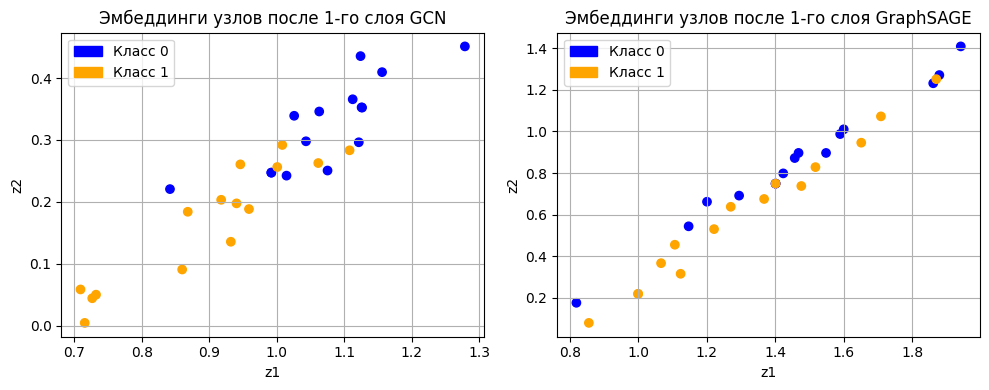

In [8]:
# Задача 7. Визуализация и сравнение эмбеддингов

model_gcn.eval()
model_sage.eval()

with torch.no_grad():
    # TODO: получите эмбеддинги после первого слоя GCN (с ReLU)
    # Обратитесь напрямую к model_gcn.gcn1 с нужными аргументами
    h_gcn1 = model_gcn.lay_1(X2_t, A2_norm_t)
    h_gcn1 = F.relu(h_gcn1)

    # TODO: получите эмбеддинги после первого слоя GraphSAGE (с ReLU)
    h_sage1 = model_sage.lay_1(X2_t)
    h_sage1 = F.relu(h_sage1)

# TODO: Переведите тензоры в numpy
h_gcn_np = h_gcn1.detach().cpu().numpy()
h_sage_np = h_sage1.detach().cpu().numpy()

# TODO: Постройте два scatter plot рядом (1 строка, 2 колонки):
# Левый — GCN, правый — GraphSAGE
# Для каждого класса (0 и 1) отдельный цвет
plt.figure(figsize=(10, 4))
colors = ['blue' if lbl == 0 else 'orange' for lbl in labels2]
class_0 = mpatches.Patch(color='blue', label='Класс 0')
class_1 = mpatches.Patch(color='orange', label='Класс 1')

plt.subplot(1, 2, 1)
# ваш код здесь — GCN
plt.scatter(h_gcn_np[:, 0], h_gcn_np[:, 3], c=colors)
plt.legend(handles=[class_0, class_1], loc='best')
plt.title("Эмбеддинги узлов после 1-го слоя GCN")
plt.xlabel("z1"); plt.ylabel("z2")
plt.grid(True)

plt.subplot(1, 2, 2)
# ваш код здесь — GraphSAGE
plt.scatter(h_sage_np[:, 0], h_sage_np[:, 3], c=colors)
plt.legend(handles=[class_0, class_1], loc='best')
plt.title("Эмбеддинги узлов после 1-го слоя GraphSAGE")
plt.xlabel("z1"); plt.ylabel("z2")
plt.grid(True)

plt.tight_layout()
plt.show()

**Интерпретация:**  
На графике модели GCN эмбединги сильнее перемешиваются и усложнено их линейное разделение. Тем не менее, части кластеров, отдалённые от переходной области, визуально различимы.  
На диаграмме модели GraphSAGE эмбединги узлов лучше разделяются линейно; меньше узлов перемешиваются. Большую часть узлов каждого класса становится возможным выделить в отдельный кластер.  
Графики построены по координатам 0 и 3 для которых при данном seed получались визуально различимые кластеры для обоих изображений. В общем случае ограниченного количества координат эмбедингов может быть недостаточно для сравнения качества двух моделей.

---

# СЛОЖНЫЕ ЗАДАЧИ (8–9)

Теперь перейдем к graph-level задачам с использованием pooling и сделаем
итоговое сравнение моделей.


## Задача 8. Graph-level классификация с pooling

### Постановка задачи

1. Сгенерировать набор синтетических графов двух разных классов (например, более разреженные и более плотные).
2. Для каждого графа задать признаки узлов и применить один шаг message passing (GCN или GraphSAGE).
3. Выполнить global mean pooling для получения эмбеддинга графа и обучить простой MLP-классификатор.

### Теоретический минимум

- В graph-level задачах агрегация по узлам (readout / pooling) превращает переменное число узлов
  в фиксированный вектор признаков графа.


In [9]:
# Задача 8. Реализация graph-level классификации
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# --- A. Генерация данных ---
torch.manual_seed(SEED)
np.random.seed(SEED)

num_graphs_per_class = 40
num_nodes_min, num_nodes_max = 10, 15

graphs = []
labels_graph = []

for cls in [0, 1]:
    for j in range(num_graphs_per_class):
        n = np.random.randint(num_nodes_min, num_nodes_max + 1)
        # TODO: Выберите вероятность ребра p в зависимости от cls (0 → разреженный, 1 → плотный)
        p = 0.05 if cls == 0 else 0.35
        # TODO: Сгенерируйте граф Эрдёша–Реньи
        seed = SEED + cls * 1000 + j # детерменированные, но различающиеся seed
        Gg = nx.erdos_renyi_graph(n, p, seed=seed)
        # TODO: Если граф не связный, возьмите наибольшую компоненту связности
        if not nx.is_connected(Gg):
            large_graph = max(nx.connected_components(Gg), key=len)
            Gg = Gg.subgraph(large_graph).copy()
        graphs.append(Gg)
        labels_graph.append(cls)

labels_graph = np.array(labels_graph, dtype=np.int64)

# --- B. Graph embedding через GCN + mean pooling ---

def graph_embedding_gcn_like(Gg):
    """
    Вычисляет эмбеддинг графа через один нормализованный шаг GCN и mean pooling.

    Возвращает:
        h_graph: np.ndarray формы (out_dim,)
    """
    A = nx.to_numpy_array(Gg, dtype=np.float32)
    n = A.shape[0]

    # TODO: Постройте матрицу признаков X: константа + нормированная степень (форма n x 2)
    deg = A.sum(axis=1).astype(np.float32)
    deg_norm = (deg - deg.min()) / (deg.max() - deg.min() + 1e-8)
    X = np.ones((n, 2), dtype=np.float32)
    X[:, 1] = deg_norm

    # TODO: Нормализованная матрица смежности (аналогично Задаче 3)
    A_hat = A + np.eye(n, dtype=np.float32)
    row_sums = A_hat.sum(axis=1)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(row_sums + 1e-8).astype(np.float32))
    A_norm = D_inv_sqrt @ A_hat @ D_inv_sqrt

    # TODO: Случайная матрица весов W формы (2, 4), масштаб ~0.1
    W = (np.random.randn(2, 4).astype(np.float32)) * 0.1

    # TODO: H = ReLU(A_norm @ X @ W)
    H = np.maximum(0, A_norm @ X @ W)

    # TODO: Mean pooling: усредните H по всем узлам → вектор формы (4,)
    h_graph = H.mean(axis=0)
    return h_graph

# Применяем функцию ко всем графам
X_graph = np.stack([graph_embedding_gcn_like(Gg) for Gg in graphs], axis=0)
print("Форма X_graph:", X_graph.shape)

# --- C. Обучение классификатора ---

# TODO: Разбейте X_graph и labels_graph на train/test (test_size=0.3, stratify=labels_graph)
X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X_graph, labels_graph, test_size=0.3, stratify=labels_graph, random_state=SEED
)

class GraphMLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        # TODO: nn.Sequential с двумя Linear слоями и ReLU между ними
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, x):
        return self.net(x)

model_graph = GraphMLP(in_dim=4, hidden_dim=16, out_dim=2).to(DEVICE)
optimizer_graph = torch.optim.Adam(model_graph.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

# TODO: Конвертируйте X_train_g, X_test_g, y_train_g, y_test_g в тензоры PyTorch
X_train_t = torch.from_numpy(X_train_g).float().to(DEVICE)
X_test_t = torch.from_numpy(X_test_g).float().to(DEVICE)
y_train_t = torch.from_numpy(y_train_g).long().to(DEVICE)
y_test_t = torch.from_numpy(y_test_g).long().to(DEVICE)

EPOCHS_GRAPH = 200

for epoch in range(EPOCHS_GRAPH):
    model_graph.train()
    optimizer_graph.zero_grad()
    # TODO: forward pass и loss
    logits_g = model_graph(X_train_t)
    loss_g = criterion(logits_g, y_train_t)
    loss_g.backward()
    optimizer_graph.step()

    if (epoch + 1) % 50 == 0:
        model_graph.eval()
        with torch.no_grad():
            # TODO: вычислите train_acc и test_acc
            pred_train = torch.argmax(model_graph(X_train_t), dim=1)
            train_acc_g = (pred_train == y_train_t).float().mean().item()
            pred_test = torch.argmax(model_graph(X_test_t), dim=1)
            test_acc_g = (pred_test == y_test_t).float().mean().item()
        print(f"Эпоха {epoch+1:3d}, loss = {loss_g.item():.4f}, train_acc = {train_acc_g:.2f}, test_acc = {test_acc_g:.2f}")

Форма X_graph: (80, 4)
Эпоха  50, loss = 0.6738, train_acc = 0.70, test_acc = 0.50
Эпоха 100, loss = 0.6515, train_acc = 0.68, test_acc = 0.46
Эпоха 150, loss = 0.6308, train_acc = 0.70, test_acc = 0.50
Эпоха 200, loss = 0.6057, train_acc = 0.70, test_acc = 0.50


**Интерпретация:**  
Полученные результаты указывают на недостаточную точность (недообученность) модели MLP-классификатора. Низкая точность модели может быть связана, как с недостаточным количеством данных для обучения, так и с плохим качеством данных - т.е. с использованием векторов, полученных при помощи mean pooling из токенов, обеспеченных необучаемой матрицей весов W.

## Задача 9. Итоговое сравнение GCN, GraphSAGE и graph-level модели

### Постановка задачи

1. Сравнить точность GCN и GraphSAGE на узловой задаче.
2. Сравнить точность graph-level модели на задачах классификации графов.
3. Сформулировать выводы: какая архитектура лучше подходит для какой постановки,
   как влияют глубина и тип агрегации.

### Теоретический минимум

- Разные архитектуры GNN по-разному используют структуру графа и признаки.
- Выбор модели зависит от типа задачи (узловая vs графовая) и требований
  к индуктивности и масштабируемости.


In [10]:
# Задача 9. Сводка метрик

# --- Узловая задача ---
model_gcn.eval()
model_sage.eval()

with torch.no_grad():
    # TODO: вычислите финальные train_acc и test_acc для GCN
    logits_gcn = model_gcn(X2_t, A2_norm_t)
    pred_gcn = torch.argmax(logits_gcn, dim=1)
    train_acc_gcn = (pred_gcn[idx_train] == labels2_t[idx_train]).float().mean().item()
    test_acc_gcn = (pred_gcn[idx_test] == labels2_t[idx_test]).float().mean().item()

    # TODO: вычислите финальные train_acc и test_acc для GraphSAGE
    logits_sage = model_sage(X2_t)
    pred_sage = torch.argmax(logits_sage, dim=1)
    train_acc_sage = (pred_sage[idx_train] == labels2_t[idx_train]).float().mean().item()
    test_acc_sage = (pred_sage[idx_test] == labels2_t[idx_test]).float().mean().item()

# --- Graph-level задача ---
model_graph.eval()
with torch.no_grad():
    # TODO: вычислите финальные train_acc и test_acc для graph-level модели
    logits_train_graph = model_graph(X_train_t)
    pred_train_graph = torch.argmax(logits_train_graph, dim=1)
    logits_test_graph = model_graph(X_test_t)
    pred_test_graph = torch.argmax(logits_test_graph, dim=1)
    train_acc_graph = (pred_train_graph == y_train_t).float().mean().item()
    test_acc_graph = (pred_test_graph == y_test_t).float().mean().item()

# --- Сводная таблица ---
print("=" * 60)
print(f"{'Модель':<25} {'train_acc':>10} {'test_acc':>10}")
print("=" * 60)
print(f"{'GCN (узловая)':<25} {train_acc_gcn:>10.3f} {test_acc_gcn:>10.3f}")
print(f"{'GraphSAGE (узловая)':<25} {train_acc_sage:>10.3f} {test_acc_sage:>10.3f}")
print(f"{'Graph MLP + pooling':<25} {train_acc_graph:>10.3f} {test_acc_graph:>10.3f}")
print("=" * 60)



Модель                     train_acc   test_acc
GCN (узловая)                  1.000      1.000
GraphSAGE (узловая)            1.000      1.000
Graph MLP + pooling            0.696      0.500


**Интерпретация:**  
* Модели GCN и GraphSAGE на узловой задаче показывают одинаковую точность. Ранее было отмечено, что для обучения более сложной модели GraphSAGE потребовалось больше эпох.  
* Модель Graph MLP + pooling показывает низкую точность на задаче классификации графов. В качестве основной причины низкой точности видится организация pooling без обучения матрицы весов W.  
* Наиболее простая модель GCN с агрегацией через нормализованную матрицу смежности высокоэффективна на узловых задачах с фиксированным графом.
* Модель GraphSAGE с явно задаваемой функцией агрегации признаков соседей также хорошо справляется с узловыми задачами с фиксированным графом, однако является для таких задач чрезмерно сложной. Более эффективно эта модель может применяться на задачах с динамическими графами (например, в которых могут появляться новые узлы), т.к. не требует повторного расчёта матрицы смежности.
* Модель Graph MLP, применяемая для классификации графов, может быть основана как на модели GCN, так и на модели GraphSAGE, которые нужны для формирования токенов узлов для векторов классифицируемых графов.
* Было показано на практике, что модели GCN и GraphSAGE могут эффективно решать узловые задачи, имея глубину в два полносвязных нейронных слоя. С другой сторы, увеличение глубины у графовых моделей (более 3 слоёв) приводит к снижению точности из-за размывания признаков узлов - теряется обобщающая способность из-за получения более однородных эмбедингов узлов.   



---

## Интерпретация результатов

В этом задании:

- мы увидели, как граф задается через матрицу смежности и матрицу признаков,
  и как базовые линейные операции реализуют message passing;
- реализовали нормализованный шаг GCN и проверили согласованность размерностей;
- обучили простую GCN-модель для классификации узлов и убедились, что структура графа
  помогает улучшить качество;
- реализовали упрощенный GraphSAGE и сравнили его поведение с GCN по качеству и
  эмбеддингам узлов;
- построили простую graph-level модель на основе одного шага message passing и pooling
  и показали, что она умеет различать классы графов.

Мы также увидели, что выбор архитектуры (GCN vs GraphSAGE) и типа pooling влияет
на разделимость классов и поведение модели на узловых и графовых задачах.


## Выводы

1. Графовые нейронные сети опираются на простые матричные операции (умножение на матрицу смежности
   и линейные преобразования), которые реализуют шаги message passing.
2. GCN использует фиксированную нормализованную матрицу \(	ilde{A}\), что делает слой компактным и
   удобным для трандуктивных задач.
3. GraphSAGE задает агрегацию соседей явно и хорошо подходит для индуктивных сценариев, где
   граф может меняться или расширяться.
4. Для graph-level задач критично использовать pooling, который агрегирует признаки узлов
   в фиксированный вектор представления графа.
5. Практический выбор архитектуры зависит от постановки: для узловых задач с фиксированным графом
   удобно использовать GCN, для более гибких сценариев и больших графов — варианты GraphSAGE,
   а для задач на графах — комбинации message passing и pooling.
